
# ICP reward-reservoir controller — concise Monte Carlo notebook, balanced paths

This notebook studies a simple mechanism to reduce **new ICP minting flow** for recurring reward payments.

## Core idea

Let:

```text
R_t = ICP that would normally be minted for rewards in month t
```

Instead of minting all `R_t`, maintain an ICP reservoir and use:

```text
if ICP price increased since last month:
    mint M1 * R_t
    pay rewards from reservoir

if ICP price decreased since last month:
    mint M2 * R_t
    pay rewards from reservoir

if the reservoir is insufficient:
    mint the residual normally
```

This is a soft controller: if the reservoir cannot cover rewards, it falls back to ordinary minting for the missing amount.


In [1]:

import math
import warnings
from dataclasses import dataclass
from typing import Optional, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_SEED = 20260518



## 1. Balanced synthetic 5-year ICP price paths

The controller is tested on diverse monthly price paths:

- steady up;
- steady down;
- flat low volatility;
- flat high volatility;
- boom-bust;
- bust-recovery;
- regime switch;
- jump up;
- jump down;
- cyclical;
- mixed GBM.

The same path library is reused for every parameter pair, so the heatmap compares policies fairly.

To keep the forum figure readable, we reject unrealistically explosive synthetic paths with terminal ratios above `MAX_TERMINAL_RATIO`. This is not because such paths are impossible, but because the first notebook’s sample plot was dominated by a few extreme up paths, visually hiding downtrends.


terminal_bucket,ends down (<0.8x),sideways (0.8–1.25x),ends up (>1.25x)
archetype,,,
boom_bust,10,5,35
bust_recovery,18,10,22
cyclical,26,10,14
flat_high_vol,24,3,23
flat_low_vol,8,33,9
gbm_mixed,16,5,29
jump_down,44,6,0
jump_up,6,8,36
regime_switch,22,7,21


,count,median,min,max
archetype,,,,
boom_bust,50,2.314091,0.112145,9.580181
bust_recovery,50,1.085321,0.148812,7.461371
cyclical,50,0.771347,0.091654,5.641035
flat_high_vol,50,1.186754,0.041280,16.839680
flat_low_vol,50,1.012197,0.552588,2.056617
gbm_mixed,50,1.725738,0.043293,24.872206
jump_down,50,0.333828,0.057495,1.220693
jump_up,50,1.847570,0.491968,10.591459
regime_switch,50,0.842202,0.064986,10.835558


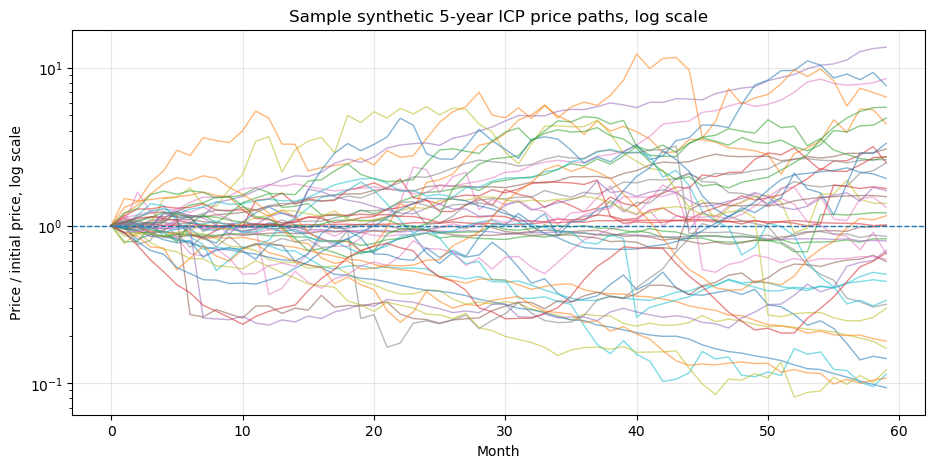

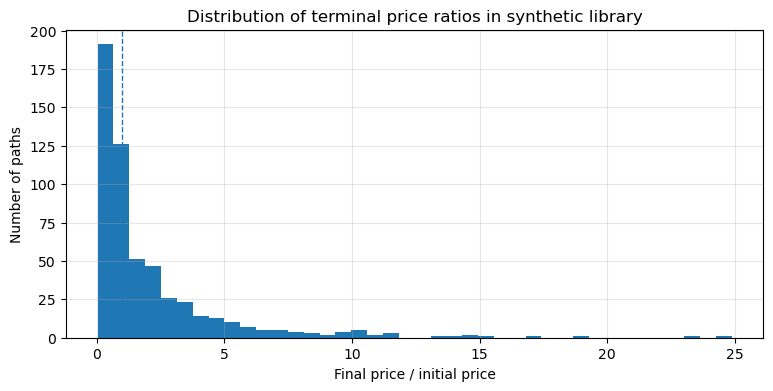

In [2]:

ARCHETYPES = [
    "gbm_mixed", "steady_up", "steady_down",
    "flat_low_vol", "flat_high_vol",
    "boom_bust", "bust_recovery", "regime_switch",
    "jump_up", "jump_down", "cyclical",
]

MIN_TERMINAL_RATIO = 0.04
MAX_TERMINAL_RATIO = 25.0


def generate_monthly_price_path(
    n_months: int = 60,
    start_price: float = 10.0,
    rng: Optional[np.random.Generator] = None,
    archetype: Optional[str] = None,
) -> Dict[str, Any]:
    if rng is None:
        rng = np.random.default_rng()
    if archetype is None:
        archetype = rng.choice(ARCHETYPES)

    dt = 1 / 12
    m = np.arange(n_months)

    if archetype == "gbm_mixed":
        drift = rng.uniform(-0.45, 0.45)
        vol = rng.uniform(0.20, 0.90)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)

    elif archetype == "steady_up":
        drift = rng.uniform(0.12, 0.50)
        vol = rng.uniform(0.04, 0.25)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)

    elif archetype == "steady_down":
        drift = rng.uniform(-0.50, -0.12)
        vol = rng.uniform(0.04, 0.25)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)

    elif archetype == "flat_low_vol":
        drift = rng.uniform(-0.04, 0.04)
        vol = rng.uniform(0.03, 0.15)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)

    elif archetype == "flat_high_vol":
        drift = rng.uniform(-0.04, 0.04)
        vol = rng.uniform(0.35, 0.90)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)

    elif archetype == "boom_bust":
        vol = rng.uniform(0.20, 0.60)
        r = 0.30 * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)
        crash_month = rng.integers(int(0.35 * n_months), int(0.85 * n_months))
        r[crash_month] += rng.uniform(np.log(0.20), np.log(0.65))

    elif archetype == "bust_recovery":
        vol = rng.uniform(0.20, 0.60)
        r = 0.25 * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)
        crash_month = rng.integers(3, int(0.35 * n_months))
        r[crash_month] += rng.uniform(np.log(0.20), np.log(0.65))

    elif archetype == "regime_switch":
        cut = rng.integers(int(0.25 * n_months), int(0.75 * n_months))
        d1, d2 = rng.uniform(-0.50, 0.50, size=2)
        v1, v2 = rng.uniform(0.12, 0.80, size=2)
        r = np.r_[
            d1 * dt + v1 * np.sqrt(dt) * rng.standard_normal(cut),
            d2 * dt + v2 * np.sqrt(dt) * rng.standard_normal(n_months - cut),
        ]

    elif archetype == "jump_up":
        drift = rng.uniform(-0.10, 0.10)
        vol = rng.uniform(0.10, 0.40)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)
        r[rng.integers(3, n_months - 3)] += rng.uniform(np.log(1.4), np.log(3.5))

    elif archetype == "jump_down":
        drift = rng.uniform(-0.10, 0.10)
        vol = rng.uniform(0.10, 0.40)
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months)
        r[rng.integers(3, n_months - 3)] += rng.uniform(np.log(0.20), np.log(0.70))

    elif archetype == "cyclical":
        drift = rng.uniform(-0.08, 0.08)
        vol = rng.uniform(0.10, 0.35)
        amp = rng.uniform(0.20, 0.70)
        period = rng.uniform(14, 36)
        cycle = amp * np.sin(2 * np.pi * m / period + rng.uniform(0, 2*np.pi))
        r = drift * dt + vol * np.sqrt(dt) * rng.standard_normal(n_months) + np.diff(np.r_[cycle[0], cycle])

    prices = start_price * np.exp(np.cumsum(r))
    prices = np.maximum(prices, 0.05)

    return {
        "prices": prices,
        "archetype": archetype,
        "terminal_ratio": prices[-1] / prices[0],
        "path_return": prices[-1] / prices[0] - 1,
    }


def generate_balanced_path_library(
    paths_per_archetype: int = 50,
    n_months: int = 60,
    seed: int = RANDOM_SEED,
    max_attempts_per_path: int = 1000,
):
    rng = np.random.default_rng(seed)
    out = []
    path_id = 0

    for arch in ARCHETYPES:
        accepted = 0
        attempts = 0
        while accepted < paths_per_archetype and attempts < paths_per_archetype * max_attempts_per_path:
            attempts += 1
            p = generate_monthly_price_path(n_months=n_months, rng=rng, archetype=arch)
            if MIN_TERMINAL_RATIO <= p["terminal_ratio"] <= MAX_TERMINAL_RATIO:
                p["path_id"] = path_id
                path_id += 1
                accepted += 1
                out.append(p)

        if accepted < paths_per_archetype:
            raise RuntimeError(f"Could not generate enough accepted paths for archetype={arch}. Accepted {accepted}.")

    return out


PATHS_PER_ARCHETYPE = 50
N_MONTHS = 60

paths = generate_balanced_path_library(PATHS_PER_ARCHETYPE, N_MONTHS)

path_meta = pd.DataFrame([
    {
        "path_id": p["path_id"],
        "archetype": p["archetype"],
        "terminal_ratio": p["terminal_ratio"],
        "path_return": p["path_return"],
    }
    for p in paths
])

path_meta["terminal_bucket"] = pd.cut(
    path_meta["terminal_ratio"],
    bins=[0, 0.80, 1.25, np.inf],
    labels=["ends down (<0.8x)", "sideways (0.8–1.25x)", "ends up (>1.25x)"],
)

display(pd.crosstab(path_meta["archetype"], path_meta["terminal_bucket"]))
display(path_meta.groupby("archetype")["terminal_ratio"].agg(["count", "median", "min", "max"]))

# Readable path sample: log axis prevents a few up paths from hiding down paths.
sample_paths = []
for arch in ARCHETYPES:
    sample_paths.extend([p for p in paths if p["archetype"] == arch][:4])

fig, ax = plt.subplots(figsize=(11, 5))
for p in sample_paths:
    ax.plot(np.arange(N_MONTHS), p["prices"] / p["prices"][0], alpha=0.55, linewidth=1)
ax.axhline(1.0, linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_title("Sample synthetic 5-year ICP price paths, log scale")
ax.set_xlabel("Month")
ax.set_ylabel("Price / initial price, log scale")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(path_meta["terminal_ratio"], bins=40)
ax.axvline(1.0, linestyle="--", linewidth=1)
ax.set_title("Distribution of terminal price ratios in synthetic library")
ax.set_xlabel("Final price / initial price")
ax.set_ylabel("Number of paths")
ax.grid(True, alpha=0.3)
plt.show()



## 2. Controller simulator

The monthly reward liability is held constant in XDR terms, so the ICP amount required varies with the price path.

The simulator reports:

```text
raw_mint_reduction_pct
    reduction in new ICP minted during the 5-year window

reserve_adjusted_reduction_pct
    raw reduction adjusted by ending reserve minus initial reserve

fallback_any
    whether the reservoir was insufficient at least once
```

For the forum post, the most relevant policy claim is about **raw minting flow**. The adjusted metric is included to keep the accounting honest.


In [3]:

@dataclass
class ReservoirPolicy:
    M1_up: float
    M2_down: float
    initial_reserve_months: float = 6.0
    liability_xdr: float = 3_000_000.0
    xdr_usd: float = 1.35


def simulate_controller(prices_usd: np.ndarray, policy: ReservoirPolicy) -> Dict[str, Any]:
    prices_xdr = prices_usd / policy.xdr_usd
    R = policy.liability_xdr / np.maximum(prices_xdr, 1e-12)

    initial_reserve = policy.initial_reserve_months * np.median(R)
    reserve = initial_reserve

    baseline_minted = 0.0
    strategy_minted = 0.0
    fallback_months = 0
    reserve_min = reserve

    for t in range(len(prices_usd)):
        baseline_reward = R[t]
        baseline_minted += baseline_reward

        if t == 0:
            M = 0.5 * (policy.M1_up + policy.M2_down)
        elif prices_usd[t] > prices_usd[t - 1]:
            M = policy.M1_up
        elif prices_usd[t] < prices_usd[t - 1]:
            M = policy.M2_down
        else:
            M = 0.5 * (policy.M1_up + policy.M2_down)

        planned_mint = M * baseline_reward
        reserve += planned_mint
        strategy_minted += planned_mint

        paid_from_reserve = min(baseline_reward, reserve)
        reserve -= paid_from_reserve

        residual = baseline_reward - paid_from_reserve
        if residual > 1e-12:
            # Fallback: mint missing amount normally.
            strategy_minted += residual
            fallback_months += 1

        reserve_min = min(reserve_min, reserve)

    raw_reduction = baseline_minted - strategy_minted
    reserve_adjusted = raw_reduction + reserve - initial_reserve

    return {
        "baseline_minted": baseline_minted,
        "strategy_minted": strategy_minted,
        "raw_mint_reduction_pct": raw_reduction / baseline_minted,
        "reserve_adjusted_reduction_pct": reserve_adjusted / baseline_minted,
        "initial_reserve": initial_reserve,
        "ending_reserve": reserve,
        "reserve_change": reserve - initial_reserve,
        "fallback_any": fallback_months > 0,
        "fallback_months": fallback_months,
        "min_reserve": reserve_min,
    }



## 3. Grid search over \(M_1, M_2\)

Interpretation:

```text
M1_up:
    fraction of baseline reward minting in months when ICP price increased

M2_down:
    fraction of baseline reward minting in months when ICP price decreased
```

The neutral baseline is:

```text
M1 = 1.0, M2 = 1.0
```

Values below 1 reduce new minting, but draw more from the reservoir.


In [4]:

M1_values = np.round(np.linspace(0.70, 1.05, 15), 3)
M2_values = np.round(np.linspace(0.70, 1.10, 17), 3)

rows = []
path_rows = []

for M1 in M1_values:
    for M2 in M2_values:
        summaries = []
        for p in paths:
            s = simulate_controller(p["prices"], ReservoirPolicy(M1_up=float(M1), M2_down=float(M2)))
            s["M1_up"] = float(M1)
            s["M2_down"] = float(M2)
            s["path_id"] = p["path_id"]
            s["archetype"] = p["archetype"]
            s["path_return"] = p["path_return"]
            summaries.append(s)

        df = pd.DataFrame(summaries)
        path_rows.append(df)

        rows.append({
            "M1_up": float(M1),
            "M2_down": float(M2),
            "median_raw_reduction_pct": df["raw_mint_reduction_pct"].median(),
            "p10_raw_reduction_pct": df["raw_mint_reduction_pct"].quantile(0.10),
            "p90_raw_reduction_pct": df["raw_mint_reduction_pct"].quantile(0.90),
            "prob_raw_positive": (df["raw_mint_reduction_pct"] > 0).mean(),

            "median_adjusted_reduction_pct": df["reserve_adjusted_reduction_pct"].median(),
            "prob_adjusted_positive": (df["reserve_adjusted_reduction_pct"] > 0).mean(),

            "fallback_prob": df["fallback_any"].mean(),
            "median_fallback_months": df["fallback_months"].median(),
            "median_reserve_change": df["reserve_change"].median(),
        })

grid = pd.DataFrame(rows)
path_results = pd.concat(path_rows, ignore_index=True)

safe_candidates = grid[grid["fallback_prob"] <= 0.05].copy()
moderate_candidates = grid[grid["fallback_prob"] <= 0.20].copy()

safe_best = safe_candidates.sort_values("median_raw_reduction_pct", ascending=False).iloc[0]
moderate_best = moderate_candidates.sort_values("median_raw_reduction_pct", ascending=False).iloc[0]
aggressive_best = grid.sort_values("median_raw_reduction_pct", ascending=False).iloc[0]

summary_table = pd.DataFrame([
    {"label": "safe <=5% fallback", **safe_best.to_dict()},
    {"label": "moderate <=20% fallback", **moderate_best.to_dict()},
    {"label": "aggressive max raw reduction", **aggressive_best.to_dict()},
])

display(summary_table[[
    "label", "M1_up", "M2_down",
    "median_raw_reduction_pct", "p10_raw_reduction_pct", "p90_raw_reduction_pct",
    "prob_raw_positive", "fallback_prob",
    "median_adjusted_reduction_pct", "prob_adjusted_positive",
    "median_reserve_change",
]])


,label,M1_up,M2_down,median_raw_reduction_pct,p10_raw_reduction_pct,p90_raw_reduction_pct,prob_raw_positive,fallback_prob,median_adjusted_reduction_pct,prob_adjusted_positive,median_reserve_change
0,safe <=5% fallback,0.950,0.925,0.062509,0.058293,0.066061,1.0,0.049091,0.0,0.469091,-1.562789e+06
1,moderate <=20% fallback,0.925,0.925,0.075000,0.072332,0.075000,1.0,0.127273,0.0,0.492727,-1.856131e+06
2,aggressive max raw reduction,0.875,0.900,0.094200,0.072332,0.105129,1.0,0.963636,0.0,0.469091,-2.405502e+06



## 4. Main figure: how to read the heatmap

The heatmap below shows the median percentage reduction in new ICP minted over 5 years.

```text
yellow / positive:
    less new ICP minted than baseline

blue / negative:
    more ICP minted than baseline

near M1=1, M2=1:
    approximately baseline
```

The strongest yellow region is not automatically the best policy. It may rely on drawing down the reservoir. Therefore read it together with the fallback-risk heatmap.


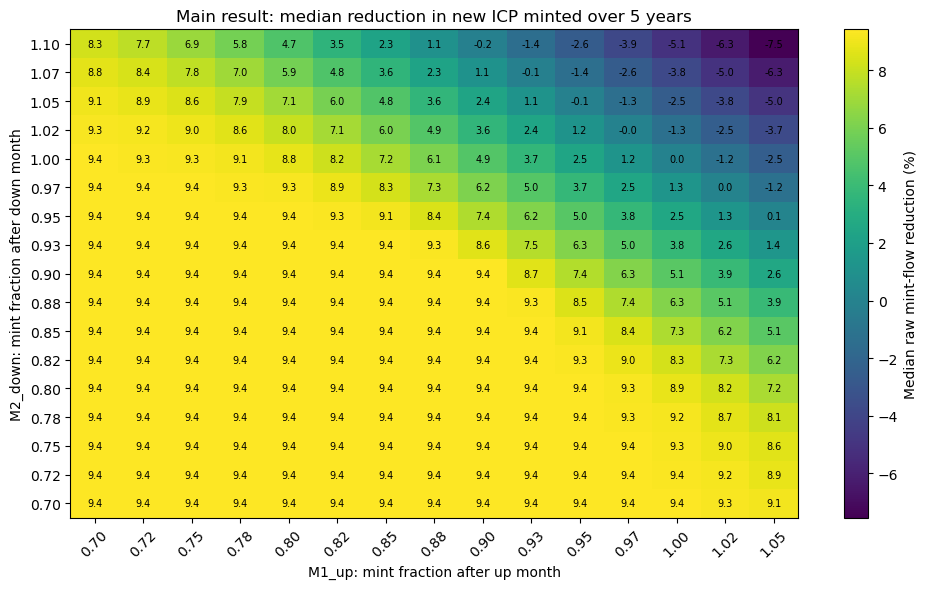

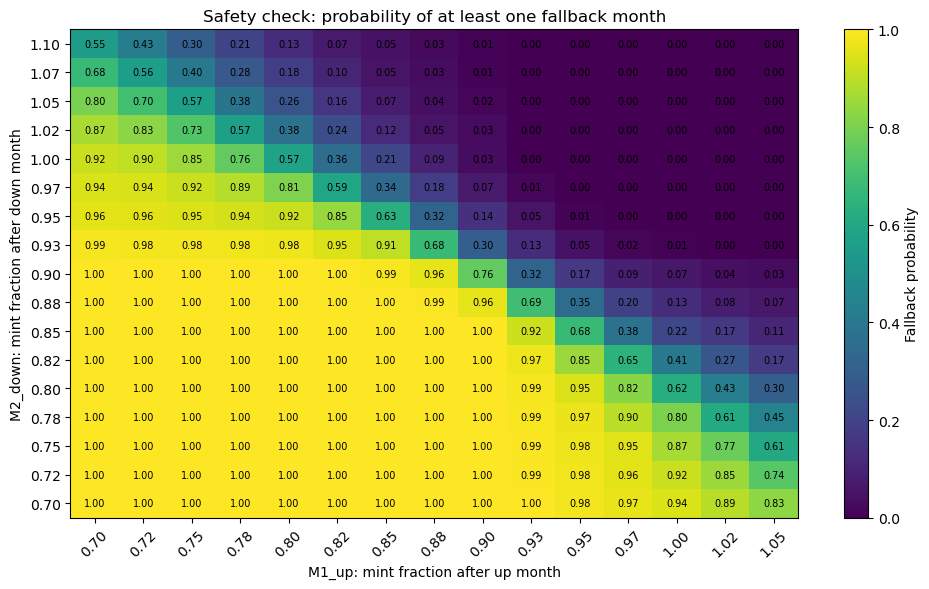

In [5]:

def plot_heatmap(data, value_col, title, cbar_label, scale=100, fmt=".1f"):
    pivot = data.pivot(index="M2_down", columns="M1_up", values=value_col).sort_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values * scale, origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([f"{x:.2f}" for x in pivot.columns], rotation=45)
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([f"{y:.2f}" for y in pivot.index])
    ax.set_xlabel("M1_up: mint fraction after up month")
    ax.set_ylabel("M2_down: mint fraction after down month")
    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j] * scale
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()


plot_heatmap(
    grid,
    "median_raw_reduction_pct",
    "Main result: median reduction in new ICP minted over 5 years",
    "Median raw mint-flow reduction (%)",
    scale=100,
    fmt=".1f",
)

plot_heatmap(
    grid,
    "fallback_prob",
    "Safety check: probability of at least one fallback month",
    "Fallback probability",
    scale=1,
    fmt=".2f",
)



## 5. Distribution of outcomes for representative policies

A single heatmap cell is only a median. This section shows the full distribution of outcomes for three representative policies:

1. safest high-reduction policy under 5% fallback probability;
2. best policy under 20% fallback probability;
3. most aggressive policy in the grid.


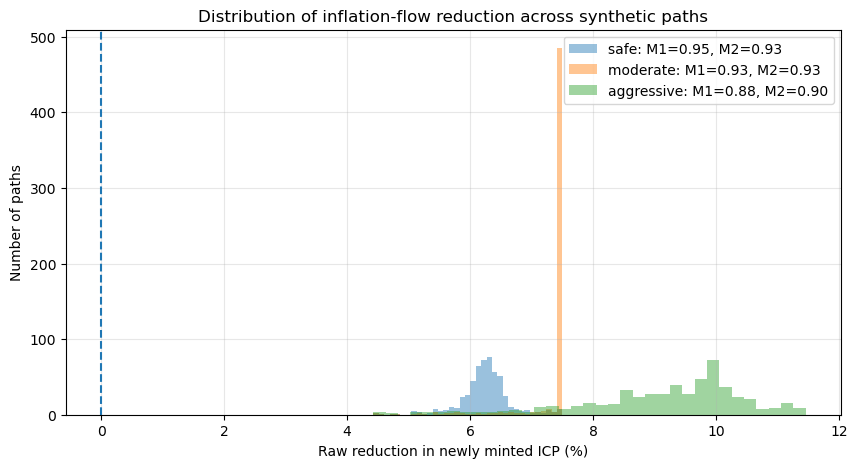

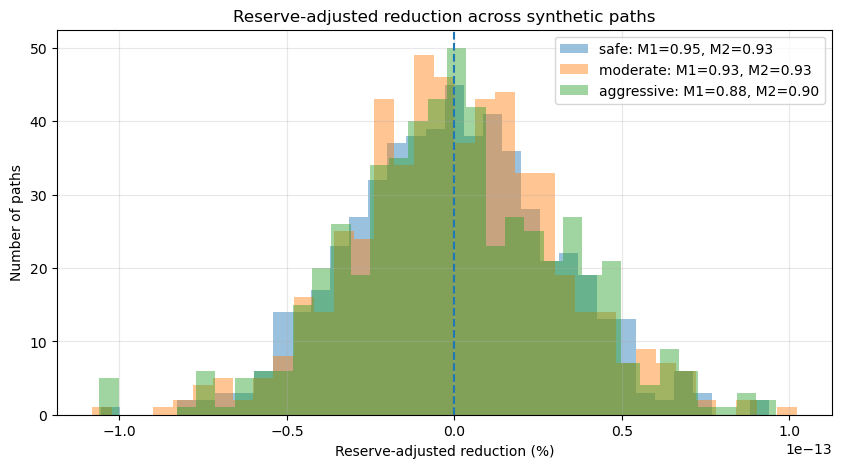

In [6]:

selected = {
    "safe": (float(safe_best["M1_up"]), float(safe_best["M2_down"])),
    "moderate": (float(moderate_best["M1_up"]), float(moderate_best["M2_down"])),
    "aggressive": (float(aggressive_best["M1_up"]), float(aggressive_best["M2_down"])),
}

fig, ax = plt.subplots(figsize=(10, 5))
for label, (M1, M2) in selected.items():
    sub = path_results[(path_results["M1_up"] == M1) & (path_results["M2_down"] == M2)]
    ax.hist(sub["raw_mint_reduction_pct"] * 100, bins=35, alpha=0.45, label=f"{label}: M1={M1:.2f}, M2={M2:.2f}")
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_title("Distribution of inflation-flow reduction across synthetic paths")
ax.set_xlabel("Raw reduction in newly minted ICP (%)")
ax.set_ylabel("Number of paths")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for label, (M1, M2) in selected.items():
    sub = path_results[(path_results["M1_up"] == M1) & (path_results["M2_down"] == M2)]
    ax.hist(sub["reserve_adjusted_reduction_pct"] * 100, bins=35, alpha=0.45, label=f"{label}: M1={M1:.2f}, M2={M2:.2f}")
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_title("Reserve-adjusted reduction across synthetic paths")
ax.set_xlabel("Reserve-adjusted reduction (%)")
ax.set_ylabel("Number of paths")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



## 6. Archetype breakdown for the safe policy

This checks whether the selected policy works only in one price regime or broadly across regimes.


In [7]:

safe_M1, safe_M2 = selected["safe"]
safe_paths = path_results[(path_results["M1_up"] == safe_M1) & (path_results["M2_down"] == safe_M2)]

archetype_summary = (
    safe_paths
    .groupby("archetype", as_index=False)
    .agg(
        paths=("path_id", "nunique"),
        median_raw_reduction_pct=("raw_mint_reduction_pct", "median"),
        p10_raw_reduction_pct=("raw_mint_reduction_pct", lambda s: s.quantile(0.10)),
        fallback_prob=("fallback_any", "mean"),
        median_adjusted_reduction_pct=("reserve_adjusted_reduction_pct", "median"),
    )
    .sort_values("median_raw_reduction_pct", ascending=False)
)

display(archetype_summary)


,archetype,paths,median_raw_reduction_pct,p10_raw_reduction_pct,fallback_prob,median_adjusted_reduction_pct
9,steady_down,50,0.069820,0.065251,0.04,0.000000e+00
2,cyclical,50,0.063451,0.061554,0.00,1.837509e-17
8,regime_switch,50,0.063365,0.059461,0.08,7.597238e-18
7,jump_up,50,0.063231,0.060815,0.00,6.922809e-17
3,flat_high_vol,50,0.063143,0.057877,0.14,7.593245e-18
4,flat_low_vol,50,0.062538,0.060307,0.00,2.032826e-17
5,gbm_mixed,50,0.062256,0.058934,0.08,-3.716726e-17
6,jump_down,50,0.062242,0.057754,0.14,4.427433e-17
1,bust_recovery,50,0.061316,0.059113,0.00,-1.867690e-17
0,boom_bust,50,0.061133,0.059166,0.06,-6.512907e-17
